

---



---



## EJEMPLO Clasificar perros y gatos

https://www.youtube.com/watch?v=DbwKbsCWPSg


In [2]:
!pip install tensorflow_datasets

In [3]:
!pip install opencv-python

In [4]:
from tensorflow import keras
from keras.utils import load_img
from keras.utils import img_to_array
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
import tensorflow_datasets as tfds
import time
import matplotlib.pyplot as plt
import cv2

2025-11-11 17:50:32.131497: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-11 17:50:32.133739: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-11 17:50:32.170420: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-11 17:50:32.171605: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-11 17:50:33.130535: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [5]:
t = time.time()

In [6]:
#Tensorflow datasets tiene error al descargar el set de perros y gatos y lo solucionaron
#el 16 de mayo pero sigue fallando en los colabs. Entonces se agrega esta linea adicional
#Mas detalle aqui: https://github.com/tensorflow/datasets/issues/3918
setattr(tfds.image_classification.cats_vs_dogs, '_URL',"https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip")

In [7]:
#Descargar el set de datos de perros y gatos
datos, metadatos = tfds.load('cats_vs_dogs', as_supervised=True, with_info=True)

In [8]:
metadatos

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.0',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_path='/home/lcc_rn_05/tensorflow_datasets/cats_vs_dogs/4.0.0',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=689.64 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=8>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, John (JD) and Howell, Jo

,image,label
0,,1 (dog)
1,,1 (dog)
2,,1 (dog)

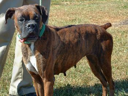
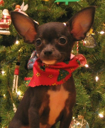
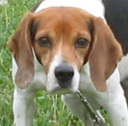

In [9]:
#Una forma de mostrar 5 ejemplos del set
tfds.as_dataframe(datos['train'].take(3), metadatos)

In [10]:
#Variable que contendra todos los pares de los datos (imagen y etiqueta) ya modificados (blanco y negro, 100x100)
datos_entrenamiento = []
TAMANO_IMG=100

In [11]:
for i, (imagen, etiqueta) in enumerate(datos['train']): #Todos los datos
  imagen = cv2.resize(imagen.numpy(), (TAMANO_IMG, TAMANO_IMG))
  imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
  imagen = imagen.reshape(TAMANO_IMG, TAMANO_IMG, 1) #Cambiar tamano a 100,100,1
  datos_entrenamiento.append([imagen, etiqueta])

Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


In [12]:
#Ver cuantos datos tengo en la variable
len(datos_entrenamiento)

23262

In [13]:
#Preparar mis variables X (entradas) y y (etiquetas) separadas

X = [] #imagenes de entrada (pixeles)
y = [] #etiquetas (perro o gato)

for imagen, etiqueta in datos_entrenamiento:
  X.append(imagen)
  y.append(etiqueta)

### Normalizar las imagenes

In [14]:
#Normalizar los datos de las X (imagenes). Se pasan a numero flotante y dividen entre 255 para quedar de 0-1 en lugar de 0-255
import numpy as np

X = np.array(X).astype(float) / 255

In [15]:
#Convertir etiquetas en arreglo simple
y = np.array(y)

In [16]:
y

array([1, 1, 1, ..., 0, 1, 0])

In [17]:
X.shape

(23262, 100, 100, 1)

### Modelo 1

In [18]:
modeloDenso1 = keras.models.Sequential([
  Input(shape=(100, 100, 1)),
  Flatten( ),
  Dense(150, activation='relu'),
  Dense(150, activation='relu'),
  Dense(50, activation='relu'),
  Dense(1, activation='sigmoid')
])

In [19]:
modeloDenso1.compile( optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'] )

In [20]:
150*50+50


7550

In [21]:
modeloDenso1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 10000)             0         
                                                                 
 dense (Dense)               (None, 150)               1500150   
                                                                 
 dense_1 (Dense)             (None, 150)               22650     
                                                                 
 dense_2 (Dense)             (None, 50)                7550      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 1530401 (5.84 MB)
Trainable params: 1530401 (5.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
#Tiempo esperado: 16 mins  GPU
%time history_Denso1 = modeloDenso1.fit( X, y, batch_size = 32, validation_split = 0.15, epochs = 50, verbose=0 )

CPU times: user 17min 7s, sys: 31.2 s, total: 17min 39s
Wall time: 3min 50s


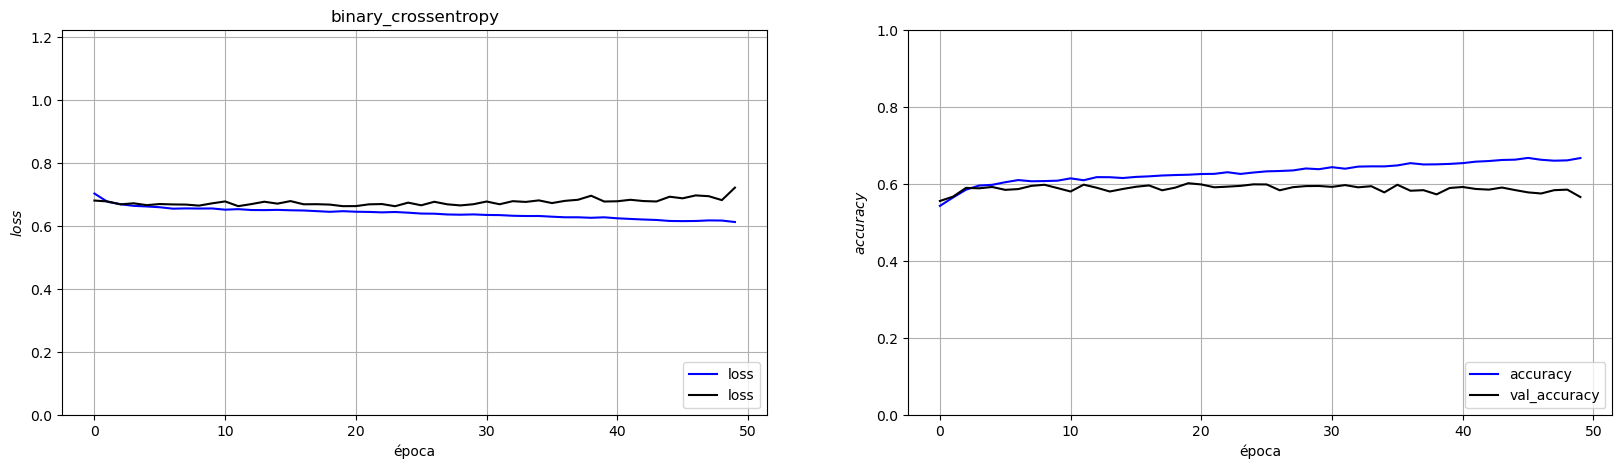

In [23]:
plt.figure( figsize=(20,5))

plt.subplot(1,2,1)
plt.plot(history_Denso1.epoch, history_Denso1.history['loss'], 'b',label='loss')
plt.plot(history_Denso1.epoch, history_Denso1.history['val_loss'], 'k',label='loss')
plt.title(u'binary_crossentropy')
plt.xlabel(u'época')
plt.ylabel(r'$loss$')
plt.ylim(0, max(max(history_Denso1.history['loss']),0.5+max(history_Denso1.history['val_loss'])))
plt.grid()
plt.legend(loc='lower right')


plt.subplot(1,2,2)
plt.plot(history_Denso1.epoch, history_Denso1.history['accuracy'], 'b',label='accuracy')
plt.plot(history_Denso1.epoch, history_Denso1.history['val_accuracy'], 'k',label='val_accuracy')
#plt.title(u'binary_crossentropy')
plt.xlabel(u'época')
plt.ylabel(r'$accuracy$')
plt.ylim(0,1)
plt.grid()
plt.legend(loc='lower right')
plt.show()

In [24]:
print(f'Tiempo de entrenamiento {(time.time() - t)/60:.5f} mins')

Tiempo de entrenamiento 4.02241 mins




---



---



# Exportar el modelo a TensorFlow.js

In [25]:
%pip install tensorflowjs

Note: you may need to restart the kernel to use updated packages.


In [26]:
import sys
print("Python version:", sys.version)
import keras
print("Keras version:", keras.__version__)
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

Python version: 3.8.18 (default, Sep 11 2023, 13:20:55) 
[GCC 11.2.0]
Keras version: 2.13.1
TensorFlow version: 2.13.1


In [29]:
#Exportar el modelo en formato h5
modeloDenso1.save('clasificador_RegularNet.h5')

In [33]:
#Para convertirlo a tensorflow.js, primero debemos instalar la libreria
!pip install tensorflowjs --use-deprecated=legacy-resolver

In [30]:
#Crear carpeta donde se colocaran los archivos resultantes
!mkdir carpeta_salida

mkdir: cannot create directory ‘carpeta_salida’: File exists


In [31]:
#Realizar la exportacion a la carpeta de salida
!tensorflowjs_converter --input_format keras clasificador_RegularNet.h5 carpeta_salida/regular

Traceback (most recent call last):
  File "/home/lcc_rn_05/.conda/envs/iris_tf/bin/tensorflowjs_converter", line 5, in <module>
    from tensorflowjs.converters.converter import pip_main
  File "/home/lcc_rn_05/.conda/envs/iris_tf/lib/python3.8/site-packages/tensorflowjs/__init__.py", line 21, in <module>
    from tensorflowjs import converters
  File "/home/lcc_rn_05/.conda/envs/iris_tf/lib/python3.8/site-packages/tensorflowjs/converters/__init__.py", line 21, in <module>
    from tensorflowjs.converters.converter import convert
  File "/home/lcc_rn_05/.conda/envs/iris_tf/lib/python3.8/site-packages/tensorflowjs/converters/converter.py", line 29, in <module>
    import tensorflow.compat.v1 as tf1
  File "/home/lcc_rn_05/.conda/envs/iris_tf/lib/python3.8/site-packages/tensorflow/__init__.py", line 38, in <module>
    from tensorflow.python.tools import module_util as _module_util
  File "/home/lcc_rn_05/.conda/envs/iris_tf/lib/python3.8/site-packages/tensorflow/python/__init__.py", lin

In [32]:
#Confirmar que en la carpeta de salida se hayan generado los archivos. Deben aparecer archivos "bin" y "json"
!ls -la carpeta_salida

total 4
drwxr-xr-x. 2 lcc_rn_05 alumnos   10 Nov 11 17:59 .
drwxr-xr-x. 4 lcc_rn_05 alumnos 4096 Nov 11 18:01 ..


In [34]:
!rm /content/carpeta_salida/group1-shard1of1.bin

rm: cannot remove '/content/carpeta_salida/group1-shard1of1.bin': No such file or directory


In [35]:
!rm /content/carpeta_salida/model.json

rm: cannot remove '/content/carpeta_salida/model.json': No such file or directory
